## seoul bike data and predicting energy consumption of day using parameters


In [181]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [182]:
data=pd.read_csv('SeoulBikeData.csv')
data.head()

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [183]:


data['Holiday']=data['Holiday'].apply(lambda x:1 if x=='Holiday' else 0)
data['Functioning Day']=data['Functioning Day'].apply(lambda x:1 if x=='Yes' else 0)
#print(data.head())
# for i in data.columns:
#     print(data[i].unique())
data['Season_winter']=data['Seasons'].apply(lambda x:1 if x=='Winter' else 0)
data['Season_Summer']=data['Seasons'].apply(lambda x:1 if x=='Summer'  else 0)
data['Season_Autumn']=data['Seasons'].apply(lambda x:1 if x=='Autumn' else 0)
data['Season_Spring']=data['Seasons'].apply(lambda x:1 if x=='Spring'  else 0)
data=data.drop('Seasons',axis=1)
data.index=data['Date']
data=data.drop('Date',axis=1)

In [186]:
data.columns
#data=data.drop('Seasons',axis=1)
print(data.columns)
data=data.groupby(data.index).mean()
data.index=pd.to_datetime(data.index,format='%d/%m/%Y')
data.head()

Index(['Rented Bike Count', 'Hour', 'Temperature(C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Holiday',
       'Functioning Day', 'Season_winter', 'Season_Summer', 'Season_Autumn',
       'Season_Spring'],
      dtype='object')


,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Season_winter,Season_Summer,Season_Autumn,Season_Spring
Date,,,,,,,,,,,,,,,,
2018-01-01,178.750000,11.5,-1.283333,39.333333,1.454167,1894.833333,-13.866667,0.255833,0.000000,0.000000,1.0,1.0,1.0,0.0,0.0,0.0
2018-02-01,224.041667,11.5,-3.866667,44.000000,1.608333,1923.625000,-15.012500,0.337083,0.000000,0.904167,0.0,1.0,1.0,0.0,0.0,0.0
2018-03-01,213.833333,11.5,0.450000,64.208333,3.554167,1084.000000,-6.387500,0.747500,0.104167,0.000000,1.0,1.0,0.0,0.0,0.0,1.0
2018-04-01,724.500000,11.5,15.183333,68.916667,1.570833,831.833333,9.370833,0.302083,0.000000,0.000000,0.0,1.0,0.0,0.0,0.0,1.0
2018-05-01,1117.500000,11.5,20.341667,72.791667,1.437500,456.458333,15.120833,0.517500,0.000000,0.000000,1.0,1.0,0.0,0.0,0.0,1.0


,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Season_winter,Season_Summer,Season_Autumn,Season_Spring
Date,,,,,,,,,,,,,,,
2018-01-01,178.750000,11.5,-1.283333,39.333333,1.454167,1894.833333,0.255833,0.000000,0.000000,1.0,1.0,1.0,0.0,0.0,0.0
2018-02-01,224.041667,11.5,-3.866667,44.000000,1.608333,1923.625000,0.337083,0.000000,0.904167,0.0,1.0,1.0,0.0,0.0,0.0
2018-03-01,213.833333,11.5,0.450000,64.208333,3.554167,1084.000000,0.747500,0.104167,0.000000,1.0,1.0,0.0,0.0,0.0,1.0
2018-04-01,724.500000,11.5,15.183333,68.916667,1.570833,831.833333,0.302083,0.000000,0.000000,0.0,1.0,0.0,0.0,0.0,1.0
2018-05-01,1117.500000,11.5,20.341667,72.791667,1.437500,456.458333,0.517500,0.000000,0.000000,1.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-05-31,1320.041667,11.5,20.525000,61.208333,1.941667,1246.208333,1.122500,0.000000,0.000000,0.0,1.0,0.0,0.0,0.0,1.0
2018-07-31,954.041667,11.5,32.525000,49.625000,1.383333,1993.791667,1.020833,0.000000,0.000000,0.0,1.0,0.0,1.0,0.0,0.0
2018-08-31,1159.041667,11.5,25.558333,67.166667,1.600000,1609.000000,0.923750,0.004167,0.000000,0.0,1.0,0.0,1.0,0.0,0.0


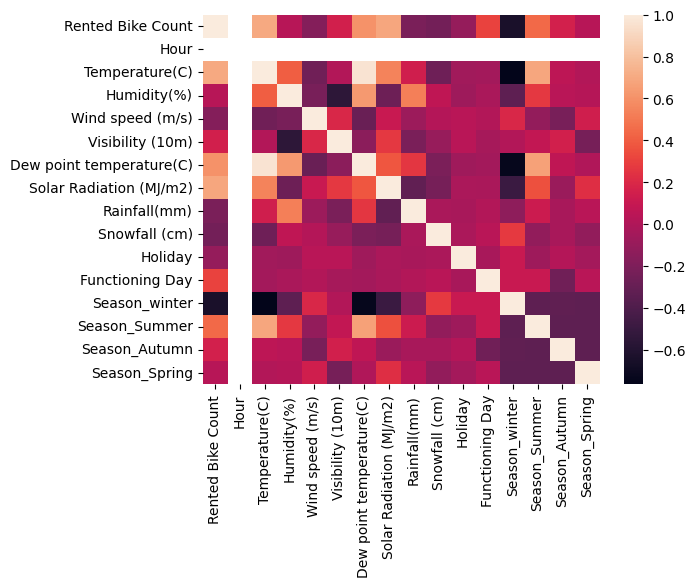

In [199]:
import seaborn as sns
sns.heatmap(data.corr())
#since dew_point temp is highly co-related remove it
data.drop('Dew point temperature(C)',axis=1)

In [215]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Scale only 'Feature1'
# data['Rented Bike Count'] = scaler.fit_transform(data[['Rented Bike Count']])
Y=data['Rented Bike Count']
X=data.drop(['Rented Bike Count','Hour'],axis=1)
print(Y)

Date
2018-01-01     178.750000
2018-02-01     224.041667
2018-03-01     213.833333
2018-04-01     724.500000
2018-05-01    1117.500000
                 ...     
2018-05-31    1320.041667
2018-07-31     954.041667
2018-08-31    1159.041667
2018-10-31     897.708333
2017-12-31     142.625000
Name: Rented Bike Count, Length: 365, dtype: float64


In [216]:

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.9)
model=LinearRegression()



In [217]:
model.fit(X,Y)

LinearRegression()

In [218]:
Y_pred=model.predict(X_test)

In [219]:
print(f'Intercept: {model.intercept_}')
print(f'Coefficient (slope): {model.coef_}')


Intercept: 385.9322335601645
Coefficient (slope): [-2.53789796e+01 -1.08275896e+01 -3.89472576e+01 -2.10026302e-02
  4.10746090e+01  5.34407277e+02 -1.29955287e+02 -2.54509677e+01
 -1.21875574e+02  9.61169181e+02 -1.70106247e+02  1.80484462e+01
  1.91231724e+02 -3.91739230e+01]


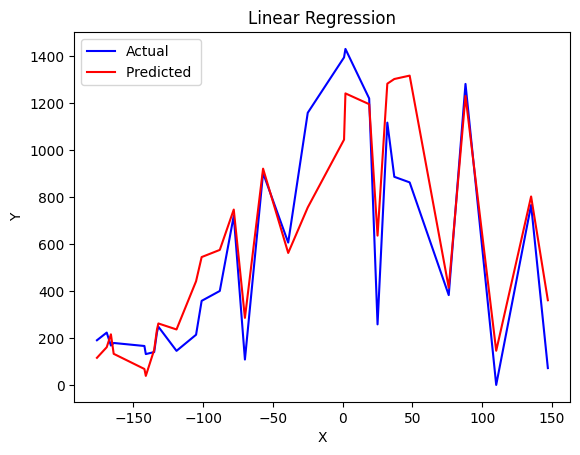

In [220]:

import matplotlib.pyplot as plt


# Assuming X_test, Y_test, and Y_pred are already defined
# Convert the datetime index to a numeric format (e.g., days since the start date)
X_test_numeric = (X_test.index - X_test.index[0]).days
sns.lineplot(x=X_test_numeric[-30:], y=Y_test[-30:], label='Actual', color='blue')

# Plot smoothed predicted values (using Lowess smoothing)
sns.lineplot(x=X_test_numeric[-30:], y=Y_pred[-30:], label='Predicted ',  color='red')

# Add labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression')
plt.legend()

# Display the plot
plt.show()


In [221]:
from sklearn.utils import resample
np.random.seed(1)
params=pd.Series(model.coef_,index=X.columns)
err = np.std([model.fit(*resample(X, Y)).coef_
for i in range(1000)], 0)
print(pd.DataFrame({'effect': params.round(0),
'error': err.round(0)}))

                          effect  error
Temperature(C)             -25.0   16.0
Humidity(%)                -11.0    4.0
Wind speed (m/s)           -39.0   17.0
Visibility (10m)            -0.0    0.0
Dew point temperature(C)    41.0   16.0
Solar Radiation (MJ/m2)    534.0   60.0
Rainfall(mm)              -130.0   29.0
Snowfall (cm)              -25.0   18.0
Holiday                   -122.0   48.0
Functioning Day            961.0   42.0
Season_winter             -170.0   29.0
Season_Summer               18.0   32.0
Season_Autumn              191.0   16.0
Season_Spring              -39.0   19.0
